In [10]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [30]:
load_dotenv()

True

In [31]:
model = ChatGoogleGenerativeAI(model="gemini-flash-latest")


In [32]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="detailed feedback on the essay")
    score: int = Field(description="score out of 10 for the essay", ge=0, le=10)

In [33]:
structured_output = model.with_structured_output(EvaluationSchema)

In [34]:
essay = """Hiiiiiii"""

In [35]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float
  

In [36]:
def evaluate_language(state: UPSCState) -> UPSCState:
    prommt = f"Evaluate the following essay for language quality and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_output.invoke(prommt)
    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [37]:
def evaluate_analysis(state: UPSCState) -> UPSCState:
    prommt = f"Evaluate the following essay for analysis quality and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_output.invoke(prommt)
    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [38]:
def evaluate_clarity(state: UPSCState) -> UPSCState:
    prommt = f"Evaluate the following essay for clarity and provide feedback and a score out of 10:\n\n{state['essay']}"
    output = structured_output.invoke(prommt)
    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [39]:
def finalize_evaluation(state: UPSCState) -> UPSCState:
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    prompt = f"""You are a senior UPSC essay examiner. Three specialist examiners have
independently reviewed the same essay. Synthesise their notes into a single, coherent
evaluation for the candidate — do not simply repeat or concatenate the notes.

Essay:
{state['essay']}

Language examiner:
{state['language_feedback']}

Analysis examiner:
{state['analysis_feedback']}

Clarity examiner:
{state['clarity_feedback']}

Average score: {avg_score:.1f}/10

Write the summary under these headings, addressing the candidate directly as "you":
1. Overall Impression - 2-3 sentences placing the essay at its level and justifying the average score.
2. Key Strengths - 2-3 bullets, each naming the specific thing the essay does well.
3. Priority Improvements - 3 bullets, ranked by impact on the score, each phrased as a concrete action.
4. Verdict - one sentence on UPSC readiness and the single biggest lever for the next attempt.

Rules: resolve disagreements between examiners rather than listing both views; be specific
and evidence-based, quoting or referring to the essay where useful; stay under 250 words."""

    overall_feedback = model.invoke(prompt).content

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [40]:
graph = StateGraph(UPSCState)

graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("finalize_evaluation", finalize_evaluation)


graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')

graph.add_edge('evaluate_language', 'finalize_evaluation')
graph.add_edge('evaluate_analysis', 'finalize_evaluation')
graph.add_edge('evaluate_clarity', 'finalize_evaluation')

graph.add_edge('finalize_evaluation', END)

workflow = graph.compile()

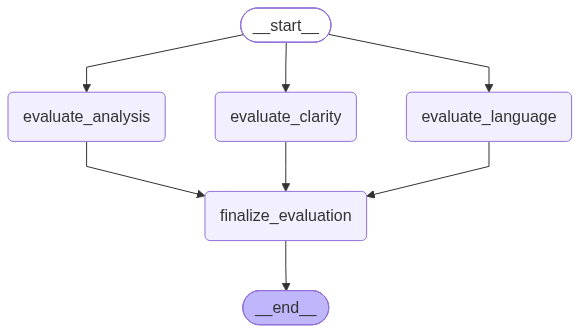

In [41]:
# display graph 
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {
    "essay": essay,
}

final_state = workflow.invoke(initial_state)
